In [1]:
import brainsss
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#from sklearn.cluster import AgglomerativeClustering
import scipy
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import fcluster
from scipy.cluster import hierarchy
from scipy.signal import butter, sosfiltfilt, filtfilt, freqz
from scipy import signal
import matplotlib as mpl
from matplotlib.pyplot import cm
import random
from scipy.stats import sem
import time
import h5py
import ants
import nibabel as nib
import matplotlib
from scipy.ndimage import gaussian_filter1d,gaussian_filter
import pickle
from skimage import io, filters
import glob
from sklearn.cluster import AgglomerativeClustering
from sklearn.feature_extraction.image import grid_to_graph
import psutil
from brainsss import brain_utils
from sklearn import linear_model
import warnings

/home/users/ilanazs/.local/lib/python3.6/site-packages/ants/viz/render_surface_function.py:16: UserWarning:

Cant import Plotly. Install it `pip install chart_studio` if you want to use ants.render_surface_function



In [2]:
fly_num = 'fly_249'

func_path = f'/oak/stanford/groups/trc/data/Ilana/2P/data/{fly_num}/'


# bg_dir = os.path.join(func_path, 'background_subtraction')
dff_path = os.path.join(func_path, 'dff')
dff_dir = os.path.join(func_path, dff_path)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [3]:
# bg_files=[]
dff_files=[]
for file in os.listdir(dff_dir):
    if '.h5' in file:
        dff_files.append(file)

In [4]:
dff_files

['functional_channel_2_moco_warp_blurred_hpf_dff.h5',
 'functional_channel_1_moco_warp_blurred_hpf_dff.h5']

In [5]:
start=1550
end=1600

In [6]:
%%time
brains={'red':[],
       'green':[]}
for file in dff_files:
    if 'dff' in file:
        path=os.path.join(dff_dir, file)
        print(path)
        with h5py.File(path, 'r') as hf:
                brain_all = hf['data'][:]
                brain=brain_all[...,start:end]
                dimsb = np.shape(brain_all)
                if '2' in file:
                    brains['green']=brain_all
                else:
                    brains['red']=brain_all
        print(f"Brain shape is {dimsb}")

/oak/stanford/groups/trc/data/Ilana/2P/data/fly_249/dff/functional_channel_2_moco_warp_blurred_hpf_dff.h5
Brain shape is (314, 146, 91, 3384)
/oak/stanford/groups/trc/data/Ilana/2P/data/fly_249/dff/functional_channel_1_moco_warp_blurred_hpf_dff.h5
Brain shape is (314, 146, 91, 3384)
CPU times: user 16.8 ms, sys: 1min 38s, total: 1min 38s
Wall time: 19min 38s


In [7]:
fixed = brainsss.load_fda_meanbrain()
# masked_r=np.where(fixed.numpy()[...,None]>0.1,brains['red'], np.nan)
# masked_g=np.where(fixed.numpy()[...,None]>0.1,brains['green'], np.nan)

In [8]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
save_dir=os.path.join(later_dir,'figs')
# plt.figure(figsize=(20,10))
# plt.imshow(np.max(masked_r[...,30,:], axis=-1).T, cmap='pink')
# plt.axis('off');
# plt.savefig(os.path.join(save_dir,'anatomical.png'), dpi=300, bbox_inches='tight')
# plt.figure(figsize=(20,10))
# plt.imshow(np.max(masked_g[...,30,:], axis=-1).T, cmap='YlGnBu_r')
# plt.axis('off');
# plt.savefig(os.path.join(save_dir,'functional.png'), dpi=300, bbox_inches='tight')

In [9]:
x,y,z=55,45,20
pixel_green=brains['green'][x,y,z,:]
pixel_red=brains['red'][x,y,z,:]

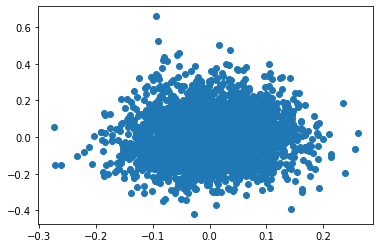

In [10]:
plt.scatter(pixel_red,pixel_green)

In [11]:
%%time
x,y,z,t=np.shape(brains['red'])
flat_red=brains['red'].reshape(x*y*z,t)
flat_green=brains['green'].reshape(x*y*z,t)
flat_sig=np.zeros_like(flat_green)
for i in range(np.shape(flat_red)[0]):
    a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
#     print(a)
    sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
#     print(sig)
    flat_sig[i,:]=sig
sig=flat_sig.reshape(x,y,z,t)

MemoryError: Unable to allocate 52.6 GiB for an array with shape (4171804, 3384) and data type float32

In [12]:
print(np.shape(sig))

NameError: name 'sig' is not defined

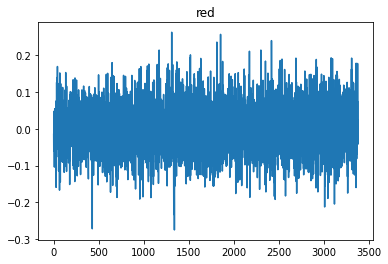

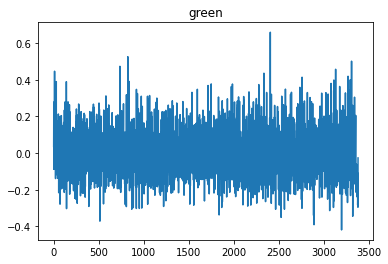

<Figure size 432x288 with 0 Axes>

In [14]:
plt.figure();
plt.plot(pixel_red);
plt.title('red');
plt.figure();
plt.plot(pixel_green);
plt.title('green');
plt.figure();
# plt.plot(sig[55,45,20,:]);
# plt.title('signal');

In [15]:
later_dir = '/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'
behave='total'
temp_path=os.path.join(later_dir,behave)
files=[]
for file in os.listdir(temp_path):
    if '208' in file:
        files.append(file)

In [16]:
files

['208_tf_total_2.h5', '208_tf_total_1.h5']

In [17]:
%%time
tf_brains={'red':[],
       'green':[]}
for file in files:
    path=os.path.join(temp_path, file)
    print(path)
    with h5py.File(path, 'r') as hf:
            brain_all = hf['brain'][:]
#             brain=brain_all[...,start:end]
            dimsb = np.shape(brain_all)
            if '_2' in file:
                tf_brains['green']=brain_all
            else:
                tf_brains['red']=brain_all
    print(f"Brain shape is {dimsb}")

/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/208_tf_total_2.h5
Brain shape is (314, 146, 91, 1030)
/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter/total/208_tf_total_1.h5
Brain shape is (314, 146, 91, 1030)
CPU times: user 38.7 ms, sys: 3min 41s, total: 3min 41s
Wall time: 52min 18s


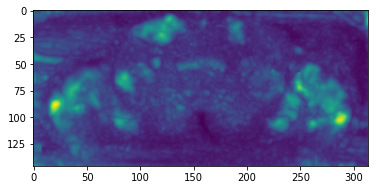

In [18]:
plt.imshow(np.nanmax(tf_brains['green'][...,40,:], axis=-1).T)

In [19]:
cluster_dir = os.path.join(later_dir, 'clustering')
giant_cluster_labels = np.load(os.path.join(cluster_dir, 'cluster_labels_best_flies.npy'))

In [20]:
n_clusters=2000
dims = np.shape(tf_brains['green'])
supervox_dict={}
for color in tf_brains:
    print(color)
    brain=tf_brains[color]
    supervox_dict[color]=[]
    for z in range(dims[-2]):
        neural_activity = brain[:,:,z,:].reshape(-1, dims[3])
        signals = []
        for cluster_num in range(n_clusters):
            cluster_indicies = np.where(giant_cluster_labels[z,:]==cluster_num)[0]
            mean_signal = np.mean(neural_activity[cluster_indicies,:], axis=0)
            signals.append(mean_signal)
        signals = np.asarray(signals)
        supervox_dict[color].append(signals)
    supervox_dict[color] = np.asarray(supervox_dict[color])
#     print(np.shape(supervox_dict[behave]['signals']))

red
green


In [21]:
for color in supervox_dict:
    supervox_dict[color]=np.nan_to_num(supervox_dict[color], nan=0, posinf=1e10, neginf=-1e10)

In [22]:
%%time
xy,z,t=np.shape(supervox_dict['red'])
flat_red=supervox_dict['red'].reshape(xy*z,t)
flat_green=supervox_dict['green'].reshape(xy*z,t)
# 5. Normalize both x and y data to improve numerical stability
x_mean, x_std = np.mean(flat_red), np.std(flat_red)
y_mean, y_std = np.mean(flat_green), np.std(flat_green)

# Avoid division by zero
if x_std == 0:
    x_std = 1.0
if y_std == 0:
    y_std = 1.0
x_normalized = (flat_red - x_mean) / x_std
y_normalized = (flat_green - y_mean) / y_std
print(x_normalized.shape)
flat_sig=np.zeros_like(flat_green)
for i in range(np.shape(flat_red)[0]):
#     a=np.polyfit(flat_red[i,:],flat_green[i,:],1)
    a=np.polyfit(x_normalized[i,:],y_normalized[i,:],1)
#     print(a)
    sig = flat_green[i,:] - (a[0]*flat_red[i,:] + a[1])
#     print(sig)
    flat_sig[i,:]=sig
supervox_sig=flat_sig.reshape(xy,z,t)

(182000, 1030)


/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

...

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

CPU times: user 24 s, sys: 1.41 s, total: 25.4 s
Wall time: 24.8 s


/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/user/open/py-jupyter/1.0.0_py36/lib/python3.6/site-packages/IPython/core/magics/execution.py:1215: RankWarning:

Polyfit may be poorly conditioned

/share/software/

In [23]:
sig_test=supervox_sig
# sig_test=supervox_dict['green']

fs=180
half_wid = 5
half_y = 500
kernel2d = np.ones((half_wid*2, half_y*2))/(4*half_wid*half_y)
conv_template = signal.convolve2d(np.mean(sig_test, axis=-1), kernel2d, boundary='symm', mode='valid')
# print(np.shape(conv_template))
test_x, test_y = np.unravel_index(np.argmin(conv_template), conv_template.shape)
test_x += half_wid
test_y += half_y


In [31]:
test_patch = sig_test[test_x-half_wid:test_x+half_wid, test_y-half_y:test_y+half_y, :]
test_patch = sig_test
test = test_patch.mean(axis=(0,1))
test = test.flatten(order='F') 
test = (test-test.mean())/test.std()

In [32]:
val=1.8*14
print(val)

25.2


(516,)


(1e-07, 1000)

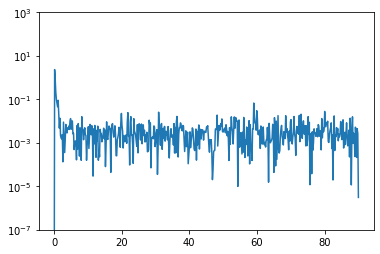

In [33]:
f, Pxx_den = signal.periodogram(test, fs)
print(np.shape(f))
plt.semilogy(f, Pxx_den)
# plt.axvline(val, c='k')
plt.ylim([1e-7, 1000])

In [37]:
xx=np.mean(np.mean(test_patch,axis=0),axis=0)
print(np.shape(xx))
xx = xx/np.max(xx)
fs=1.80
f0 = 2 # Frequency to be removed from signal (Hz)
Q = 2.0  # Quality factor
freqs_p0, psd_p0 = scipy.signal.periodogram(xx, fs=fs)

(1030,)


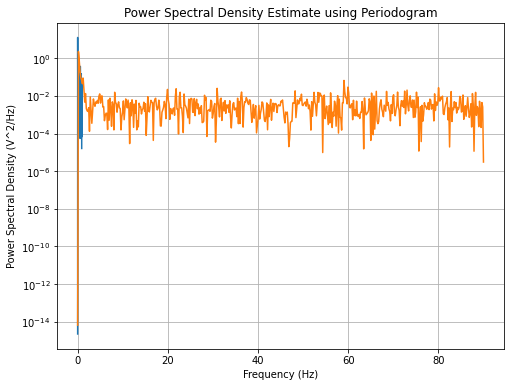

In [39]:
plt.figure(figsize=(8, 6))
plt.semilogy(freqs_p0, psd_p0)
plt.semilogy(f, Pxx_den)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power Spectral Density (V^2/Hz)')
plt.title('Power Spectral Density Estimate using Periodogram')
plt.grid(True)
# plt.ylim([1e-6, 0.2])
plt.show()

In [ ]:
later_dir= f'/oak/stanford/groups/trc/data/Ilana/2P/data/later/temp_filter'

In [ ]:
os.listdir(later_dir)

In [ ]:
data=os.path.join(later_dir,'individual_supervox_dict.h5')

with open(data, 'rb') as file:
    loaded_data = pickle.load(file)

In [ ]:
np.shape(loaded_data[fly])

In [ ]:
# [208,209, 210,217,218,226,227,228,233,234,239,240,241,242,249,250]
test_flies=['241','242','249','250']
fig, axs=plt.subplots(ncols=1, nrows=len(test_flies),figsize=(10,30))
for i,fly in enumerate(test_flies):
    z,xy,t=np.shape(loaded_data[fly])
    test=np.reshape(loaded_data[fly],(z*xy,t))
    test_mean=np.nanmean(test,axis=0)
    axs[i].plot(test_mean, color='k')
    axs[i].set_ylim((-0.02,0.02))
    

In [ ]:
avgs=[]
for key in loaded_data:
    temp = np.asarray(loaded_data[key])[...,:1024]
    mean = np.nanmean(temp, axis=(0,1))
    avgs.append(mean)

In [ ]:
avgs=np.asarray(avgs)
print(avgs.shape)
total_avg=np.nanmean(avgs,axis=0)
print(total_avg.shape)

In [ ]:
total_avg

In [ ]:
fig, axs=plt.subplots(figsize=(15,10))

axs.plot(avgs.T, color='gray', alpha=0.3);
axs.plot(total_avg, color='k', lw=4)
axs.set_ylim(-0.02,0.03);
# axs.axvline(160,color='k',linestyle='--',lw=2)
# axs.axvline(60,color='k',linestyle='--',lw=2)